<div style="background: linear-gradient(135deg, #123b5d, #1f6f8b); color: white; padding: 28px; border-radius: 12px;">
  <h1 style="margin: 0;">GBU 2301: Business Statistics</h1>
  <h2 style="margin: 8px 0 18px 0; font-weight: 400;">Week 5: Discrete Probability Distributions I</h2>
  <p style="margin: 0; font-size: 1.05em;">Fall 2026 | Dr. Omer Cayirli | Assistant Professor of Finance</p>
</div>

Required reading: Anderson et al., Statistics for Business and Economics, 15th ed., Sections 5.1–5.4

---

### Outline

* Random Variables
* Developing Discrete Probability Distributions
* Expected Value and Variance
* Bivariate Distributions and Covariance
* Financial Portfolios

---

### Random Variables

A random variable assigns a numerical value to each outcome of a random experiment.

* $X$ denotes the random variable; $x$ denotes a possible value.
* Once the experiment occurs, the observed outcome determines the value of $X$.

Inspect a single-item order. Let $X$ be the number of damaged items:

| Outcome | Value of $X$ |
|---|---:|
| Item is not damaged | 0 |
| Item is damaged | 1 |

The event $X=1$ is the event that the item is damaged. Its probability is written $P(X=1)$.

---

### Random Variables: Two Customers

Observe whether each of two customers makes a purchase. Let $B$ denote a purchase and $N$ no purchase.

Define $X$ as the number of customers who purchase.

| First customer | Second customer | Value of $X$ |
|---|---|---:|
| $N$ | $N$ | 0 |
| $B$ | $N$ | 1 |
| $N$ | $B$ | 1 |
| $B$ | $B$ | 2 |

There are four experimental outcomes but only three possible values of $X$.

$$\{X=1\}=\{(B,N),(N,B)\}$$

The probability of one purchase includes both outcomes.

---

### Discrete and Continuous Random Variables

A discrete random variable has a finite or countably infinite set of possible values. A continuous random variable can take any value within an interval or collection of intervals.

| Experiment | Random variable | Possible values | Type |
|---|---|---|---|
| Contact five customers | Number who purchase | $0,1,2,3,4,5$ | Discrete |
| Model hourly customer arrivals | Number arriving in an hour | $0,1,2,\ldots$ | Discrete |
| Select one of three contracts | Commission in MAD | $150,\ 225.50,\ 400$ | Discrete |
| Time a customer service call | Call duration in minutes | $t>0$ | Continuous |

Discrete values need not be integers. A measured duration remains conceptually continuous even when recorded to the nearest minute.

---

### Exercise 1

A salesperson contacts two clients. Each may accept or decline an offer.

| Client | Commission if the offer is accepted |
|---|---:|
| Beta | 400 MAD |
| Gamma | 600 MAD |

No commission is paid for a declined offer.

Let $X$ be the number of accepted offers and $Y$ the total commission.

a. List the possible accept/decline outcomes and the corresponding values of $X$ and $Y$.

b. If $X=1$, what can be concluded about $Y$? If $Y=600$, what can be concluded about $X$ and the clients' decisions?

c. Classify $X$ and $Y$ as discrete or continuous.

---

### Discrete Probability Distributions

The probability function $f(x)=P(X=x)$ assigns a probability to each possible value of $X$.

For the two customers, assume independent decisions and a purchase probability of $0.40$ for each customer.

| $x$: purchases | Outcomes | $f(x)$ |
|---|---|---:|
| 0 | $(N,N)$ | $0.60(0.60)=0.36$ |
| 1 | $(B,N)$ or $(N,B)$ | $0.40(0.60)+0.60(0.40)=0.48$ |
| 2 | $(B,B)$ | $0.40(0.40)=0.16$ |

A valid discrete probability distribution satisfies

$$f(x)\geq0\quad\text{for every }x,\qquad \sum_x f(x)=1$$

Here, $0.36+0.48+0.16=1$. The three possible purchase counts are not equally likely.

---

### Daily Sales: An Empirical Distribution

Beta Electronics starts each day with two units of a tablet model and does not restock during the day. Define $X$ as the number sold.

Records from 100 comparable days give:

| Units sold, $x$ | Number of days | Estimated probability, $f(x)$ |
|---|---:|---:|
| 0 | 20 | $20/100=0.20$ |
| 1 | 50 | $50/100=0.50$ |
| 2 | 30 | $30/100=0.30$ |
| Total | 100 | $1.00$ |

These probabilities are estimated from relative frequencies. Using them for a future day assumes comparable sales conditions.

A distribution may instead use a specified random mechanism or judgment-based probabilities for future scenarios.

---

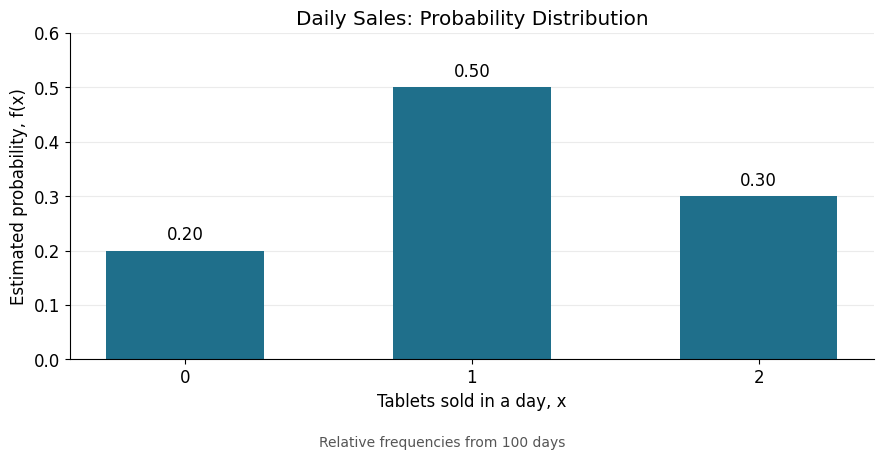

In [1]:
import matplotlib.pyplot as plt

units_sold = [0, 1, 2]
days = [20, 50, 30]
probabilities = [count / sum(days) for count in days]

with plt.rc_context({"font.size": 12, "axes.spines.top": False,
                     "axes.spines.right": False}):
    fig, ax = plt.subplots(figsize=(9, 4.6))
    bars = ax.bar(units_sold, probabilities, width=0.55, color="#1f6f8b")
    ax.bar_label(bars, labels=[f"{p:.2f}" for p in probabilities], padding=5)
    ax.set(
        title="Daily Sales: Probability Distribution",
        xlabel="Tablets sold in a day, x",
        ylabel="Estimated probability, f(x)",
        xticks=units_sold,
        ylim=(0, 0.60),
    )
    ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    fig.text(0.5, 0.01, "Relative frequencies from 100 days",
             ha="center", fontsize=10, color="#555555")
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    plt.show()


### Probabilities from a Distribution

Using the daily-sales probabilities $f(0)=0.20$, $f(1)=0.50$, and $f(2)=0.30$:

| Event | Notation | Calculation |
|---|---|---|
| Exactly one tablet sold | $P(X=1)$ | $0.50$ |
| At most one tablet sold | $P(X\leq1)$ | $0.20+0.50=0.70$ |
| At least one tablet sold | $P(X\geq1)$ | $0.50+0.30=0.80$ |
| More than one tablet sold | $P(X>1)$ | $0.30$ |
| Between one and two tablets sold, inclusive | $P(1\leq X\leq2)$ | $0.50+0.30=0.80$ |

The complement gives the same result:

$$P(X\geq1)=1-P(X=0)=1-0.20=0.80$$

“At least one” includes one; “more than one” does not.

---

### Discrete Uniform Distribution

If a random variable has $k$ possible values and each is equally likely, its probability function is

$$f(x)=\frac{1}{k}\quad\text{for each possible value of }x.$$

A customer randomly draws one of four equally likely vouchers. Their values are 10, 20, 30, and 40 MAD. Let $X$ be the voucher value.

| $x$ (MAD) | 10 | 20 | 30 | 40 |
|---|---:|---:|---:|---:|
| $f(x)$ | 0.25 | 0.25 | 0.25 | 0.25 |

$$P(X\geq30)=f(30)+f(40)=0.25+0.25=0.50$$

The number of possible values alone does not justify equal probabilities. Daily tablet sales have three possible values, but their probabilities are $0.20,\ 0.50,\ 0.30$.

---

### Exercise 2

Gamma Couriers receives a daily service adjustment under a delivery contract. A negative adjustment is a deduction; a positive adjustment is a bonus.

| Adjustment, $X$ (MAD) | $-100$ | $0$ | $200$ | $400$ |
|---|---:|---:|---:|---:|
| Probability, $f(x)$ | $0.15$ | $a$ | $2a$ | $0.10$ |

These are the only possible adjustments.

a. Determine $a$ and complete the probability distribution.

b. What is the probability that the adjustment is strictly below 200 MAD?

c. A separate daily charge of 200 MAD must be covered entirely by that day's adjustment. The firm requires at least a 70% probability of full coverage. Does this arrangement meet the requirement?

---

### Expected Value

The expected value is a probability-weighted average of the possible values of a random variable:

$$E(X)=\mu=\sum_x xf(x)$$

For Beta Electronics' daily tablet sales:

| Tablets sold, $x$ | $f(x)$ | $xf(x)$ |
|---|---:|---:|
| 0 | 0.20 | $0(0.20)=0.00$ |
| 1 | 0.50 | $1(0.50)=0.50$ |
| 2 | 0.30 | $2(0.30)=0.60$ |
| Total | 1.00 | $1.10$ |

$$E(X)=0(0.20)+1(0.50)+2(0.30)=1.10\text{ tablets per day}$$

The expected value describes the long-run daily average under this distribution, not sales on a particular day. Selling 1.10 tablets is impossible; the most likely daily sale is one tablet.

---

### Variance and Standard Deviation

Variance weights each squared deviation from the mean by its probability:

$$\operatorname{Var}(X)=\sigma^2=\sum_x(x-\mu)^2f(x),\qquad \sigma=\sqrt{\operatorname{Var}(X)}$$

Using $\mu=1.10$ for daily tablet sales:

| $x$ | $f(x)$ | $x-\mu$ | $(x-\mu)^2$ | $(x-\mu)^2f(x)$ |
|---|---:|---:|---:|---:|
| 0 | 0.20 | $-1.10$ | 1.21 | $1.21(0.20)=0.242$ |
| 1 | 0.50 | $-0.10$ | 0.01 | $0.01(0.50)=0.005$ |
| 2 | 0.30 | $0.90$ | 0.81 | $0.81(0.30)=0.243$ |

$$\sigma^2=0.242+0.005+0.243=0.49\text{ tablets}^2,\qquad \sigma=\sqrt{0.49}=0.70\text{ tablets}$$

These calculations describe a probability distribution. There is no division by $n-1$: the squared deviations are already weighted by their probabilities.

---

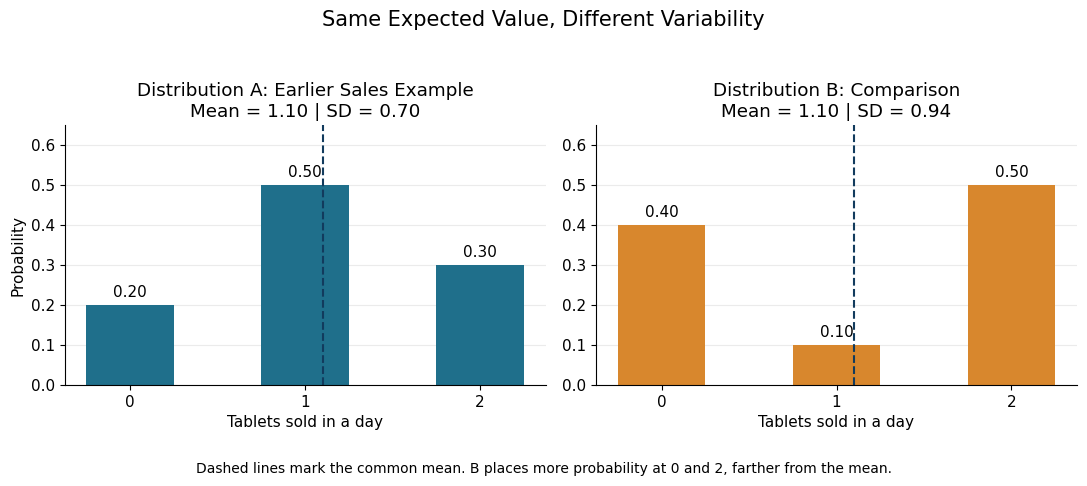

In [2]:
import numpy as np
import matplotlib.pyplot as plt

sales_values = np.array([0, 1, 2])
sales_distributions = [
    ("Distribution A: Earlier Sales Example", np.array([0.20, 0.50, 0.30])),
    ("Distribution B: Comparison", np.array([0.40, 0.10, 0.50])),
]

with plt.rc_context({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False}):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)
    for ax, (label, probabilities), color in zip(
        axes, sales_distributions, ["#1f6f8b", "#d8872d"]
    ):
        mean = np.sum(sales_values * probabilities)
        variance = np.sum((sales_values - mean) ** 2 * probabilities)
        bars = ax.bar(sales_values, probabilities, width=0.5, color=color)
        ax.bar_label(bars, labels=[f"{p:.2f}" for p in probabilities], padding=4)
        ax.axvline(mean, color="#123b5d", linestyle="--", linewidth=1.5)
        ax.set_title(f"{label}\nMean = {mean:.2f} | SD = {variance ** 0.5:.2f}")
        ax.set(xlabel="Tablets sold in a day", xticks=sales_values,
               ylim=(0, 0.65))
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)
    axes[0].set_ylabel("Probability")
    axes[1].tick_params(labelleft=True)
    fig.suptitle("Same Expected Value, Different Variability", fontsize=15)
    fig.text(
        0.5, 0.015,
        "Dashed lines mark the common mean. B places more probability at 0 and 2, farther from the mean.",
        ha="center", fontsize=10,
    )
    fig.tight_layout(rect=(0, 0.07, 1, 0.94))
    plt.show()


### Exercise 3

Return to Gamma Couriers' daily service adjustment from Exercise 2. The completed distribution is:

| Adjustment, $X$ (MAD) | $-100$ | $0$ | $200$ | $400$ |
|---|---:|---:|---:|---:|
| Probability, $f(x)$ | 0.15 | 0.25 | 0.50 | 0.10 |

a. Calculate the expected adjustment, variance, and standard deviation. State the units.

b. Find $P(X<E(X))$. Is the expected adjustment itself a possible daily outcome?

---

### An Alternative Variance Calculation

Expand the squared deviation in the definition:

$$\begin{aligned}
\operatorname{Var}(X)
&=\sum_x(x-\mu)^2f(x)\\
&=\sum_x x^2f(x)-2\mu\sum_x xf(x)+\mu^2\sum_x f(x)\\
&=E(X^2)-2\mu(\mu)+\mu^2(1)\\
&=E(X^2)-[E(X)]^2
\end{aligned}$$

Check the daily tablet-sales variance:

$$E(X^2)=0^2(0.20)+1^2(0.50)+2^2(0.30)=1.70$$

$$\operatorname{Var}(X)=1.70-(1.10)^2=1.70-1.21=0.49$$

$E(X^2)$ averages the squared outcomes; $[E(X)]^2$ squares the mean. They are different quantities.

---

### From Sales to Profit

Beta Electronics earns 80 MAD per tablet after unit costs and pays a fixed daily operating cost of 120 MAD.

With $X$ tablets sold, net daily profit is $Y=80X-120$.

| $x$: tablets sold | Probability | $y=80x-120$ (MAD) | $yf(x)$ |
|---|---:|---:|---:|
| 0 | 0.20 | $80(0)-120=-120$ | $-120(0.20)=-24$ |
| 1 | 0.50 | $80(1)-120=-40$ | $-40(0.50)=-20$ |
| 2 | 0.30 | $80(2)-120=40$ | $40(0.30)=12$ |

$$E(Y)=-24-20+12=-32\text{ MAD}$$

$$\operatorname{Var}(Y)=(-120+32)^2(0.20)+(-40+32)^2(0.50)+(40+32)^2(0.30)$$
$$=1{,}548.80+32+1{,}555.20=3{,}136\text{ MAD}^2,\qquad \sigma_Y=56\text{ MAD}$$

Expected net profit is $-32$ MAD. A loss occurs when $X=0$ or $X=1$, with probability $0.20+0.50=0.70$.

---

### Linear Transformations

For constants $a$ and $b$, let $Y=aX+b$.

$$\begin{aligned}
E(Y)&=\sum_x(ax+b)f(x)\\
&=a\sum_x xf(x)+b\sum_x f(x)=aE(X)+b
\end{aligned}$$

The deviation of each transformed outcome from its mean is

$$y-E(Y)=(ax+b)-(a\mu+b)=a(x-\mu).$$

Therefore,

$$\operatorname{Var}(Y)=\sum_x[a(x-\mu)]^2f(x)=a^2\operatorname{Var}(X),\qquad \sigma_Y=|a|\sigma_X.$$

For $Y=80X-120$:

$$E(Y)=80(1.10)-120=-32,\qquad \operatorname{Var}(Y)=80^2(0.49)=3{,}136,\qquad \sigma_Y=80(0.70)=56.$$

The fixed cost shifts every profit by the same amount, so it changes the mean but not the variance.

---

### Exercise 4

Beta Electronics considers two alternative sales arrangements. Assume the choice does not change the daily sales distribution.

The table gives net daily profit after all fees.

| Tablets sold, $x$ | Probability | Arrangement A (MAD) | Arrangement B (MAD) |
|---|---:|---:|---:|
| 0 | 0.20 | $-20$ | 10 |
| 1 | 0.50 | 80 | 70 |
| 2 | 0.30 | 180 | 130 |

a. Calculate expected daily profit and its standard deviation under each arrangement.

b. The owner requires expected daily profit of at least 80 MAD and a standard deviation no greater than 60 MAD. Which arrangement, if either, meets both requirements?

---

### Bivariate Distributions

A bivariate probability distribution describes two random variables together. Each outcome is a pair $(x,y)$.

The earlier Beta Electronics sales records refer to its North outlet. Now include its South outlet for the same 100 days.

* $X$: tablets sold at North, which starts each day with two tablets.
* $Y$: tablets sold at South, which starts each day with one tablet.
* Neither outlet restocks during the day.

| North sales, $x$ | South: $y=0$ | South: $y=1$ | Total days |
|---|---:|---:|---:|
| 0 | 15 | 5 | 20 |
| 1 | 20 | 30 | 50 |
| 2 | 5 | 25 | 30 |
| Total days | 40 | 60 | 100 |

For example, on 30 days North sold one tablet and South also sold one.

---

### Joint and Marginal Probabilities

Divide each count by 100. The joint probability function is

$$f(x,y)=P(X=x,\ Y=y).$$

| North sales, $x$ | $y=0$ | $y=1$ | $f_X(x)$ |
|---|---:|---:|---:|
| 0 | 0.15 | 0.05 | 0.20 |
| 1 | 0.20 | 0.30 | 0.50 |
| 2 | 0.05 | 0.25 | 0.30 |
| $f_Y(y)$ | 0.40 | 0.60 | 1.00 |

$$P(X=1,\ Y=1)=f(1,1)=\frac{30}{100}=0.30$$

The marginal distributions describe each outlet separately:

$$f_X(x)=\sum_y f(x,y),\qquad f_Y(y)=\sum_x f(x,y).$$

For example, $f_X(1)=0.20+0.30=0.50$ and $f_Y(1)=0.05+0.30+0.25=0.60$. All joint probabilities are nonnegative and sum to one.

---

### Conditional Probability and Independence

What is the probability that South sells its tablet, given that North sells both tablets?

$$P(Y=1\mid X=2)=\frac{P(X=2,\ Y=1)}{P(X=2)}=\frac{0.25}{0.30}=\frac{25}{30}\approx0.833$$

Without information about North, $P(Y=1)=0.60$. Knowing that North sold both tablets changes the probability for South.

Random variables $X$ and $Y$ are independent if

$$f(x,y)=f_X(x)f_Y(y)\quad\text{for every possible pair }(x,y).$$

For the pair $(2,1)$:

$$f(2,1)=0.25\ne f_X(2)f_Y(1)=0.30(0.60)=0.18.$$

Thus the two outlets' sales are not independent in this empirical distribution. One pair that fails the equality is enough to rule out independence.

---

### Means and Variances from the Marginals

| Tablets sold | North: $f_X(x)$ | South: $f_Y(y)$ |
|---|---:|---:|
| 0 | 0.20 | 0.40 |
| 1 | 0.50 | 0.60 |
| 2 | 0.30 | 0.00 |

For North:

$$\mu_X=0(0.20)+1(0.50)+2(0.30)=1.10$$

$$\sigma_X^2=(0-1.10)^2(0.20)+(1-1.10)^2(0.50)+(2-1.10)^2(0.30)=0.49$$

For South:

$$\mu_Y=0(0.40)+1(0.60)=0.60$$

$$\sigma_Y^2=(0-0.60)^2(0.40)+(1-0.60)^2(0.60)=0.144+0.096=0.24$$

The means are in tablets, the variances in tablets squared. The standard deviations are $\sigma_X=0.70$ and $\sigma_Y=\sqrt{0.24}\approx0.490$ tablets.

---

### The Distribution of Total Sales

Let $S=X+Y$ be total daily tablet sales across both outlets.

Different pairs can produce the same total. Add their joint probabilities:

| Total sales, $s$ | Pairs $(x,y)$ | $P(S=s)$ |
|---|---|---:|
| 0 | $(0,0)$ | $0.15$ |
| 1 | $(0,1),\ (1,0)$ | $0.05+0.20=0.25$ |
| 2 | $(1,1),\ (2,0)$ | $0.30+0.05=0.35$ |
| 3 | $(2,1)$ | $0.25$ |

$$E(S)=0(0.15)+1(0.25)+2(0.35)+3(0.25)=1.70\text{ tablets}$$

This equals the sum of the two means:

$$E(X+Y)=E(X)+E(Y)=1.10+0.60=1.70.$$

Expected values add even when the variables are not independent.

---

### Variance of Total Sales

Using the total-sales distribution and $E(S)=1.70$:

| $s$ | $P(S=s)$ | $s-1.70$ | $(s-1.70)^2$ | $(s-1.70)^2P(S=s)$ |
|---|---:|---:|---:|---:|
| 0 | 0.15 | $-1.70$ | 2.89 | $2.89(0.15)=0.4335$ |
| 1 | 0.25 | $-0.70$ | 0.49 | $0.49(0.25)=0.1225$ |
| 2 | 0.35 | 0.30 | 0.09 | $0.09(0.35)=0.0315$ |
| 3 | 0.25 | 1.30 | 1.69 | $1.69(0.25)=0.4225$ |

$$\operatorname{Var}(S)=0.4335+0.1225+0.0315+0.4225=1.01\text{ tablets}^2$$

$$\sigma_S=\sqrt{1.01}\approx1.005\text{ tablets}$$

Adding the separate variances gives only $0.49+0.24=0.73$. The difference, $1.01-0.73=0.28$, reflects how the outlets' sales move together.

---

### Covariance

Covariance is the probability-weighted average of the products of deviations from the two means:

$$\operatorname{Cov}(X,Y)=\sigma_{XY}=\sum_x\sum_y(x-\mu_X)(y-\mu_Y)f(x,y).$$

Here, $\mu_X=1.10$ and $\mu_Y=0.60$.

| $(x,y)$ | $f(x,y)$ | $(x-1.10)(y-0.60)$ | Weighted product |
|---|---:|---:|---:|
| $(0,0)$ | 0.15 | $(-1.10)(-0.60)=0.66$ | $0.66(0.15)=0.099$ |
| $(0,1)$ | 0.05 | $(-1.10)(0.40)=-0.44$ | $-0.44(0.05)=-0.022$ |
| $(1,0)$ | 0.20 | $(-0.10)(-0.60)=0.06$ | $0.06(0.20)=0.012$ |
| $(1,1)$ | 0.30 | $(-0.10)(0.40)=-0.04$ | $-0.04(0.30)=-0.012$ |
| $(2,0)$ | 0.05 | $(0.90)(-0.60)=-0.54$ | $-0.54(0.05)=-0.027$ |
| $(2,1)$ | 0.25 | $(0.90)(0.40)=0.36$ | $0.36(0.25)=0.090$ |

$$\sigma_{XY}=0.099-0.022+0.012-0.012-0.027+0.090=0.14\text{ tablets}^2$$

Deviations with the same sign give positive products; opposite signs give negative products.

---

### Covariance and the Variance of a Sum

Since $E(X+Y)=\mu_X+\mu_Y$, the deviation of total sales is

$$(X+Y)-E(X+Y)=(X-\mu_X)+(Y-\mu_Y).$$

Expand its square and take the probability-weighted average:

$$\begin{aligned}
\operatorname{Var}(X+Y)
&=E\left[\big((X-\mu_X)+(Y-\mu_Y)\big)^2\right]\\
&=E[(X-\mu_X)^2]+E[(Y-\mu_Y)^2]+2E[(X-\mu_X)(Y-\mu_Y)]\\
&=\sigma_X^2+\sigma_Y^2+2\sigma_{XY}.
\end{aligned}$$

For the two outlets:

$$\operatorname{Var}(X+Y)=0.49+0.24+2(0.14)=1.01.$$

Solving for covariance:

$$\sigma_{XY}=\frac{\operatorname{Var}(X+Y)-\operatorname{Var}(X)-\operatorname{Var}(Y)}{2}
=\frac{1.01-0.49-0.24}{2}=0.14.$$

Positive covariance increases the variance of the total relative to the sum of the separate variances; negative covariance reduces it.

---

### Correlation

For two variables with positive standard deviations, correlation expresses covariance on a unit-free scale:

$$\rho_{XY}=\frac{\sigma_{XY}}{\sigma_X\sigma_Y},\qquad -1\leq\rho_{XY}\leq1.$$

For the two outlets:

$$\rho_{XY}=\frac{0.14}{\sqrt{0.49}\sqrt{0.24}}\approx0.408.$$

Sales have a positive linear association: higher sales at North tend to accompany higher sales at South.

* Values nearer $+1$ or $-1$ indicate stronger linear association.
* Zero correlation means no linear association, not necessarily independence.
* Independence implies zero covariance and correlation when the variances are finite and positive.

For these 100-day records, the probability-weighted calculation and the sample correlation give the same result.

---

### Exercise 5

Gamma Supplies has one pending order from each of two clients. Each order is either confirmed today or not confirmed.

Let $X=1$ if the first client's order is confirmed and $Y=1$ if the second client's order is confirmed; otherwise the corresponding variable is zero.

| $X$ | $Y=0$ | $Y=1$ |
|---|---:|---:|
| 0 | 0.10 | 0.30 |
| 1 | 0.50 | 0.10 |

a. Obtain the marginal distributions. Calculate the mean and variance of each variable.

b. Let $S=X+Y$. Find its distribution, expected value, and variance. A vehicle can collect only one confirmed order today. What is the probability that this capacity is insufficient?

c. Calculate covariance and correlation. Explain their connection to the variance of $S$. Are the two confirmations independent?

---

### Financial Portfolios

A portfolio combines investments. Consider two hypothetical funds over the same one-year period:

| Economic state | Probability | Fund Alpha: $R_A$ (%) | Fund Beta: $R_B$ (%) |
|---|---:|---:|---:|
| Weak | 0.25 | $-4$ | 12 |
| Moderate | 0.50 | 8 | 6 |
| Strong | 0.25 | 20 | 4 |

The state determines both returns. The entries in a row occur together.

If fractions $w_A$ and $w_B$ of the initial investment go into the two funds, the portfolio return is

$$R_p=w_AR_A+w_BR_B,\qquad w_A+w_B=1.$$

Here, weights are nonnegative: no borrowing or short selling.

Returns are entered as percent numbers: 8 means 8%. Standard deviations are in percentage points; variances and covariances are in squared percentage points.

---

### Expected Returns and Risk

$$E(R_A)=(-4)(0.25)+8(0.50)+20(0.25)=8\%$$
$$E(R_B)=12(0.25)+6(0.50)+4(0.25)=7\%$$

Calculate variance from the deviations within each state:

| State | $p$ | $(R_A-8)^2p$ | $(R_B-7)^2p$ |
|---|---:|---:|---:|
| Weak | 0.25 | $(-12)^2(0.25)=36$ | $5^2(0.25)=6.25$ |
| Moderate | 0.50 | $0^2(0.50)=0$ | $(-1)^2(0.50)=0.50$ |
| Strong | 0.25 | $12^2(0.25)=36$ | $(-3)^2(0.25)=2.25$ |

$$\sigma_A^2=36+0+36=72,\qquad \sigma_A=\sqrt{72}\approx8.485$$
$$\sigma_B^2=6.25+0.50+2.25=9,\qquad \sigma_B=3$$

Alpha has the higher expected return and the higher variability. Neither expected return is a guaranteed one-year return.

---

### Covariance of Returns

Using $E(R_A)=8$ and $E(R_B)=7$:

| State | $p$ | $R_A-8$ | $R_B-7$ | Deviation product | Weighted product |
|---|---:|---:|---:|---:|---:|
| Weak | 0.25 | $-12$ | 5 | $(-12)(5)=-60$ | $-60(0.25)=-15$ |
| Moderate | 0.50 | 0 | $-1$ | $0(-1)=0$ | $0(0.50)=0$ |
| Strong | 0.25 | 12 | $-3$ | $12(-3)=-36$ | $-36(0.25)=-9$ |

$$\operatorname{Cov}(R_A,R_B)=\sigma_{AB}=\sum_s p_s(R_{A,s}-8)(R_{B,s}-7)=-15+0-9=-24$$

Here, $s$ indexes the economic states and $p_s$ is the probability of state $s$.

$$\rho_{AB}=\frac{-24}{\sqrt{72}\sqrt{9}}\approx-0.943$$

The returns have a strong negative linear association in this model. Combining them can offset some of their variation, but the correlation is not $-1$.

---

### A 50/50 Portfolio

Invest half in each fund. Calculate the portfolio return within each state:

| State | $p$ | $R_p=0.50R_A+0.50R_B$ (%) | $(R_p-7.50)^2p$ |
|---|---:|---:|---:|
| Weak | 0.25 | $0.50(-4)+0.50(12)=4$ | $(-3.50)^2(0.25)=3.0625$ |
| Moderate | 0.50 | $0.50(8)+0.50(6)=7$ | $(-0.50)^2(0.50)=0.1250$ |
| Strong | 0.25 | $0.50(20)+0.50(4)=12$ | $4.50^2(0.25)=5.0625$ |

$$E(R_p)=4(0.25)+7(0.50)+12(0.25)=7.50\%$$

$$\operatorname{Var}(R_p)=3.0625+0.1250+5.0625=8.25$$

$$\sigma_p=\sqrt{8.25}\approx2.872\text{ percentage points}$$

The portfolio has a higher expected return than Beta alone, with a lower standard deviation: $7.50\%>7\%$ and $2.872<3$.

---

### Portfolio Expected Return and Variance

Taking the probability-weighted average across states:

$$E(R_p)=\sum_s p_s(w_AR_{A,s}+w_BR_{B,s})=w_AE(R_A)+w_BE(R_B).$$

Let $\mu_A=E(R_A)$, $\mu_B=E(R_B)$, and $\mu_p=E(R_p)$. The portfolio deviation is

$$R_p-\mu_p=w_A(R_A-\mu_A)+w_B(R_B-\mu_B).$$

Square this expression and take its expected value:

$$\begin{aligned}
\operatorname{Var}(R_p)
&=w_A^2E[(R_A-\mu_A)^2]+w_B^2E[(R_B-\mu_B)^2]\\
&\quad+2w_Aw_BE[(R_A-\mu_A)(R_B-\mu_B)]\\
&=w_A^2\sigma_A^2+w_B^2\sigma_B^2+2w_Aw_B\sigma_{AB}.
\end{aligned}$$

Check the 50/50 portfolio:

$$E(R_p)=0.50(8)+0.50(7)=7.50\%$$
$$\operatorname{Var}(R_p)=0.50^2(72)+0.50^2(9)+2(0.50)(0.50)(-24)=18+2.25-12=8.25.$$

Portfolio variance uses squared weights and a covariance term, not a weighted average of the individual variances.

---

### Exercise 6

Using the same one-year scenarios, invest 25% in Alpha and 75% in Beta.

| Economic state | Probability | Alpha return (%) | Beta return (%) |
|---|---:|---:|---:|
| Weak | 0.25 | $-4$ | 12 |
| Moderate | 0.50 | 8 | 6 |
| Strong | 0.25 | 20 | 4 |

a. Calculate the portfolio return in each state, its expected return, and its standard deviation. Check the variance using the portfolio formula.

b. Compare this allocation with Alpha alone, Beta alone, and the 50/50 portfolio. Which alternatives, if any, offer both a lower expected return and a higher standard deviation than the 25/75 portfolio? Is there one best choice for every investor?

---

### What is next?

* Discrete Probability Distributions II
    * Binomial Probability Distribution
    * Poisson Probability Distribution
    * Hypergeometric Probability Distribution

* Reading(s):
    * SBE Sections 5.5–5.7

---

### Exercise 7

Delta Foods must stock two, three, or four boxes of a perishable product before daily demand is known.

| Daily demand, $D$ (boxes) | 1 | 2 | 3 | 4 |
|---|---:|---:|---:|---:|
| Probability | 0.10 | 0.30 | 0.40 | 0.20 |

Each box costs 40 MAD, sells for 70 MAD, and can be sold for salvage at 10 MAD if left over at the end of the day.

Demand is unaffected by the stocking choice. Sales cannot exceed available stock. Unmet demand is lost, with no additional penalty; there are no other costs.

Evaluate the three stocking quantities and recommend one. Justify the financial and service trade-offs numerically.

---

### Exercise 8

Two outlets share a collection service. Let $X$ and $Y$ be the numbers of orders ready at the first and second outlets on a morning.

| $X$ | $Y=0$ | $Y=1$ |
|---|---:|---:|
| 0 | 0.10 | 0.10 |
| 1 | 0.20 | 0.20 |
| 2 | 0.10 | 0.30 |

a. Find the distribution, mean, and variance of total orders $S=X+Y$.

b. Calculate $\operatorname{Cov}(X,Y)$ and use it to check the variance of $S$. Find $P(Y=1\mid X=2)$.

c. The regular vehicle holds two orders. Each excess order is outsourced for 60 MAD. Alternatively, one extra place can be reserved before the orders are known for a fixed 25 MAD, paid even if unused.

Choose the option with the lowest expected additional cost among those that require outsourcing on no more than 10% of mornings. Assume all excess orders can be outsourced.

---

### Exercise 9

An investor allocates 20,000 MAD between two hypothetical funds for one year, with no borrowing or short selling.

| Economic state | Probability | Gamma return (%) | Delta return (%) |
|---|---:|---:|---:|
| Weak | 0.25 | $-2$ | 8 |
| Moderate | 0.50 | 6 | 2 |
| Strong | 0.25 | 14 | 4 |

a. Find the allocation that gives an expected portfolio return of 5%. State the amounts invested in each fund.

b. Calculate the portfolio variance and standard deviation. A worksheet reports a variance of 9.50 squared percentage points for this allocation. Determine whether this is correct and identify the calculation behind that figure.

c. Find the probability of losing money under these scenarios. Does the result establish that the investment is risk-free?

---